# GoalLab Stage 07: Learn preferences over cited evidence

Created by Shivam Bharadwaj · [Course home](../../../README.md) · [Stage map](../STAGES.md)

[Stage 06](06_ppo.ipynb) · [Stage 08](08_one_problem_many_algorithms.ipynb)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/apply-theory/07_preference_and_grpo.ipynb)

**Build:** learn preferences for supported citations, then optimize a separate citation policy with DPO.

**Run:** use the full repository, install `requirements.txt` (Stage 09 also uses `requirements-modern.txt`), then restart the kernel and run all cells. Every stage reconstructs its inputs from shared GoalLab modules; earlier notebook execution is not required. The project progression is cumulative in capabilities, without hidden notebook state.

Code: MIT. Text and plots: CC BY 4.0. Results below are reproduced from the supplied GoalLab cases; the evaluation section explains their scope and failure cases.

**Learn the algorithm first:** [Course Notebook 07](../../../notebooks/07_preference_and_grpo.ipynb). Then use this GoalLab stage to apply it to evidence gathering and briefing verification.


In [1]:
import sys, subprocess, platform, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'rl_course').is_dir()), Path.cwd())
if IN_COLAB and not (ROOT / 'rl_course').exists():
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(ROOT)], check=True)
if not (ROOT / 'rl_course' / 'goallab.py').exists():
    raise FileNotFoundError('Use the complete repository revision containing the GoalLab stages.')
sys.path.insert(0, str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Markdown, display
from rl_course import goallab as goal
from rl_course import goallab_learning as learning
torch.set_num_threads(2)
%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#af824a', '#768165', '#87708c', '#f5f1e8'
plt.rcParams.update({'figure.figsize': (9, 4), 'figure.dpi': 110, 'figure.facecolor': PAPER,
    'axes.facecolor': PAPER, 'text.color': INK, 'axes.labelcolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]), 'axes.grid': True, 'grid.alpha': .15})
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
        '\n'.join('| ' + ' | '.join(str(x).replace('|', '&#124;').replace('\n', '<br>') for x in row) + ' |' for row in rows)))
def learning_plot(runs):
    for label, run in runs.items():
        h = run['history']
        plt.plot(h[:, 0], h[:, 1], label=label)
    plt.xlabel('Training environment actions'); plt.ylabel('Exact policy return')
    plt.legend(); plt.tight_layout(); plt.show()
def report_policies(runs):
    table(['Controller', 'Exact return', 'Held-out briefing success', 'Calls/case'],
          [[label, round(run['env'].values(run['policy'])[0][run['env'].start_index], 3),
            f"{learning.heldout(run['policy'])['success']:.1%}", learning.heldout(run['policy'])['calls']]
           for label, run in runs.items()])
workspace = goal.make_workspace(7, 'test')
print(f'{goal.VERSION} | Python {platform.python_version()} | NumPy {np.__version__} | Torch {torch.__version__} | CPU')

GoalLab-v1 | Python 3.12.4 | NumPy 1.26.4 | Torch 2.11.0+cu130 | CPU


## Shared contract

One source is an approved measurement for the requested period. Other sources are drafts or forecasts, deliberately newer and numerically different. Training rows use 0..3; held-out rows use 4..7 and a different period. Authority rules stay the same. `search` reveals IDs and timestamps; `read` reveals content. A valid briefing needs the correct value, period, and citation.

The simulator and models are readable teaching code, not a security boundary. Final `verify()` is outside the policy interface. The first eight stages use a finite two-source abstraction: read twice, choose a citation, then submit or claim completion. Claiming completion produces no briefing. This fixed horizon makes exact comparisons possible; later stages vary investigation budgets.

## Learning objectives and the stage contract

Build preference pairs; train a ranking model; explain why DPO does not consume that reward model.

**Input:** the shared evidence workspace or the preceding component reconstructed below. **Output:** the capability named in this stage, evaluated against the common briefing contract. Read the worked calculation before running the full experiment; then inspect the implementation and predict the constraint exercise.

## Work it out: preference margins and reference anchoring

Pairwise reward learning increases the chosen-minus-rejected score. DPO instead increases the policy log-probability margin relative to a fixed reference margin. The reference terms cancel for a uniform two-action reference, but that is a property of this lab, not a general omission from DPO.

At initialization the policy equals its reference, so the DPO loss is `log(2)`. A good preference score still needs an independent check of citation support.

In [2]:
beta=.5
policy_margin=torch.tensor([0.,2.]); reference_margin=torch.zeros(2)
loss=-torch.nn.functional.logsigmoid(beta*(policy_margin-reference_margin))
print('DPO losses at margins 0 and 2:',loss.tolist())
assert np.isclose(loss[0],np.log(2)) and loss[1]<loss[0]

DPO losses at margins 0 and 2: [0.6931471824645996, 0.3132616877555847]


## Build the component

The central implementation is included here so you can step through and edit the update or tool logic. The shared modules retain the same reference implementation for the integrated project. Inspect shapes, terminal handling, frozen quantities, and the evaluator boundary before training.

In [3]:
from collections import deque
from copy import deepcopy
from torch import nn
from torch.distributions import Categorical
EvidenceMDP = goal.EvidenceMDP
greedy = learning.greedy
network = learning.network
from rl_course.goallab_preferences import evidence_features
make_workspace=goal.make_workspace
verify=goal.verify
Briefing=goal.Briefing
def preference_lab(seed=7, steps=100):
    """Two contexts, two citations. Synthetic rules, not human annotations.

    Reward model uses pairwise logistic loss. DPO uses a fixed uniform reference.
    The model sees evidence eligibility; this isolates preference mechanics.
    """
    torch.manual_seed(seed)
    workspaces = [make_workspace(i) for i in range(40)]
    x = evidence_features(workspaces)
    chosen = x.argmax(1)
    rejected = 1 - chosen
    reward_model = nn.Linear(2, 2)
    optimizer = torch.optim.Adam(reward_model.parameters(), lr=.05)
    for _ in range(steps):
        scores = reward_model(x)
        loss = -nn.functional.logsigmoid(scores.gather(1, chosen[:, None]) - scores.gather(1, rejected[:, None])).mean()
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    # Separate direct-preference policy; reward model is NOT used by DPO.
    policy = nn.Linear(2, 2, bias=False)
    nn.init.zeros_(policy.weight)
    optimizer = torch.optim.Adam(policy.parameters(), lr=.05)
    history = []
    for i in range(steps):
        logp = policy(x).log_softmax(-1)
        margin = logp.gather(1, chosen[:, None]) - logp.gather(1, rejected[:, None])
        loss = -nn.functional.logsigmoid(.5 * margin).mean()
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        history.append(float(loss.detach()))
    test = [make_workspace(i, 'test') for i in range(100)]
    with torch.no_grad():
        tx = evidence_features(test)
        reward_accuracy = float((reward_model(tx).argmax(1) == tx.argmax(1)).float().mean())
        actions = policy(tx).argmax(1).tolist()
        verified = np.mean([verify(w, Briefing(w.sources[a].value, w.sources[a].source_id, w.period))['success']
                            for w, a in zip(test, actions)])
    return {'reward_accuracy': reward_accuracy, 'success': float(verified), 'loss': history,
            'model': policy, 'reward_model': reward_model}

## 1. Synthetic preference pairs

Both sources have already been read in this stage. Choose the approved measurement over the draft. A pairwise logistic reward model learns which citation is preferred. A separate DPO policy learns directly from these pairs against a fixed uniform reference; it does not use the reward model.

This two-action demonstration isolates objective mechanics. Labels are generated rules, not human preference data, and approval features make the task intentionally easy.

Held-out reward-model ranking: 1.0
Verified briefing success: 1.0


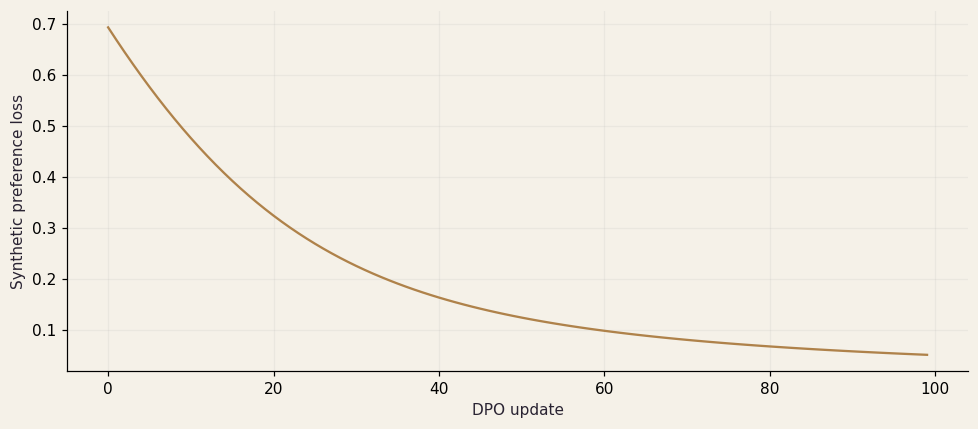

In [4]:
from rl_course import goallab_preferences as preferences
run = preference_lab()
print('Held-out reward-model ranking:',run['reward_accuracy'])
print('Verified briefing success:',run['success'])
plt.plot(run['loss']); plt.xlabel('DPO update'); plt.ylabel('Synthetic preference loss'); plt.tight_layout(); plt.show()

## 2. Preferences are not factual truth

A preference for newer documents can be learned perfectly and still choose unsupported figures. Use the independent briefing evaluator to examine the consequence.

In [5]:
wrong = goal.baseline(workspace,newest=True)
right = goal.baseline(workspace)
table(['Preference','Final verification'],[['Newest source',goal.verify(workspace,wrong.artifact)],['Approved measurement',goal.verify(workspace,right.artifact)]])

| Preference | Final verification |
|---|---|
| Newest source | {'success': False, 'supported': False, 'value_correct': False} |
| Approved measurement | {'success': True, 'supported': True, 'value_correct': True} |

## Interpret the evidence

Perfect synthetic preference accuracy is attainable because eligibility is explicit in the features. This stage teaches objectives and evaluator separation. General language understanding is not established by this easy ranking problem.

## Change a constraint: predict first

Replace the citation on an otherwise correct artifact with the draft citation. Does a correct number alone pass?

### Worked solution

Run this after writing your prediction. Compare the changed condition with the reference condition above.

In [6]:
truth = right.artifact
draft = next(s for s in workspace.sources if not goal.usable(s,workspace.period))
unsupported = goal.Briefing(truth.value,draft.source_id,workspace.period)
print(goal.verify(workspace,unsupported))
assert not goal.verify(workspace,unsupported)['success']

{'success': False, 'supported': False, 'value_correct': True}


## What this stage contributes

A preference-learning component connected to briefing verification. Stage 09 extends this to real pretrained token-level training; stage 10 uses group rewards. Theory: [reward models](../../../chapters/37-reward-models-and-preference-learning/README.md), [DPO](../../../chapters/38-direct-preference-optimization/README.md).

[Stage 06](06_ppo.ipynb) · [Stage 08](08_one_problem_many_algorithms.ipynb)